# Detekcija napada na mrežu
## Predmet: Sistemi za analizu i istraživanje podataka
 
**Skup podataka**: NSL-KDD (Network Security Laboratory & KDD)  
**Cilj**: Evaluacija i poređenje više klasifikatora za rešavanje problema napada na mrežu

This notebook implements a complete data science pipeline for intrusion detection, including:
- Data loading and exploratory analysis
- Data preprocessing and feature engineering
- Model training with multiple algorithms
- Comprehensive evaluation and comparison
- Model persistence for deployment

## 1. Import Required Libraries

In [40]:
# Import standard libraries
import numpy as np
import pandas as pd
import os
import warnings
import time
import pickle
import joblib
from pathlib import Path

# Data preprocessing and analysis
import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

✓ All libraries imported successfully!
Pandas version: 3.0.1
NumPy version: 2.4.2
Scikit-learn version: 1.8.0


## 2. Load and Explore Dataset

In [ ]:
# Define data paths and column names
import sklearn

DATA_PATH = Path('../data')

# NSL-KDD Feature names (41 features + 1 label + difficulty level)
FEATURE_NAMES = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
    'urgent', 'hot', 'num_failed_logins', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate'
]

# Attack type column and difficulty level column in TXT files
COLUMNS_WITH_LABELS = FEATURE_NAMES + ['attack_type', 'difficulty_level']

# Load training dataset (using 20% subset for faster training)
print("Loading training data...")
df_train = pd.read_csv(
    DATA_PATH / 'KDDTrain+_20Percent.txt',
    header=None,
    names=COLUMNS_WITH_LABELS,
    engine='c'
)

print("Loading test data...")
df_test = pd.read_csv(
    DATA_PATH / 'KDDTest+.txt',
    header=None,
    names=COLUMNS_WITH_LABELS,
    engine='c'
)

print(f"\n✓ Data loaded successfully!")
print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

# Display basic information
print("\n" + "="*60)
print("TRAINING DATASET - FIRST FEW ROWS")
print("="*60)
print(df_train.head())

print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
print(f"\nData types:\n{df_train.dtypes}")

print(f"\nMissing values in training set:\n{df_train.isnull().sum().sum()}")
print(f"Missing values in test set:\n{df_test.isnull().sum().sum()}")

# Basic statistics
print("\n" + "="*60)
print("BASIC STATISTICS (Training Set)")
print("="*60)
print(df_train.describe())

In [ ]:
# Exploratory Data Analysis - Attack Type Distribution
print("\n" + "="*60)
print("ATTACK TYPE DISTRIBUTION")
print("="*60)

print("\nTraining Set - Attack Type Counts:")
print(df_train['attack_type'].value_counts())
print(f"\nTotal attack types: {df_train['attack_type'].nunique()}")

print("\nTest Set - Attack Type Counts:")
print(df_test['attack_type'].value_counts())

# Create binary classification (normal vs attack)
df_train_binary = df_train.copy()
df_test_binary = df_test.copy()

df_train_binary['class'] = (df_train['attack_type'] != 'normal').astype(int)
df_test_binary['class'] = (df_test['attack_type'] != 'normal').astype(int)

print("\n" + "="*60)
print("BINARY CLASSIFICATION DISTRIBUTION (Normal vs Attack)")
print("="*60)
print("\nTraining Set:")
print(df_train_binary['class'].value_counts())
print(f"Normal: {(df_train_binary['class']==0).sum()}, Attack: {(df_train_binary['class']==1).sum()}")

print("\nTest Set:")
print(df_test_binary['class'].value_counts())
print(f"Normal: {(df_test_binary['class']==0).sum()}, Attack: {(df_test_binary['class']==1).sum()}")

In [ ]:
# Visualization - Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for training set
class_counts_train = df_train_binary['class'].value_counts().sort_index()
axes[0].bar(['Normal', 'Attack'], class_counts_train.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Training Set - Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Bar plot for test set
class_counts_test = df_test_binary['class'].value_counts().sort_index()
axes[1].bar(['Normal', 'Attack'], class_counts_test.values, color=['green', 'red'], alpha=0.7)
axes[1].set_title('Test Set - Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class distribution visualization saved")

# Protocol type distribution
print("\n" + "="*60)
print("PROTOCOL TYPE DISTRIBUTION")
print("="*60)
print(df_train['protocol_type'].value_counts())

## 3. Data Preprocessing and Cleaning

In [ ]:
print("Starting data preprocessing...")

# Create working copies
df_train_prep = df_train_binary.copy()
df_test_prep = df_test_binary.copy()

# Check for missing values
print("\nMissing values check:")
print(f"Training set: {df_train_prep.isnull().sum().sum()} missing values")
print(f"Test set: {df_test_prep.isnull().sum().sum()} missing values")

# Check for duplicates
print(f"\nDuplicate rows in training set: {df_train_prep.duplicated().sum()}")
print(f"Duplicate rows in test set: {df_test_prep.duplicated().sum()}")

# Remove duplicates if any
if df_train_prep.duplicated().sum() > 0:
    print("Removing duplicates from training set...")
    df_train_prep = df_train_prep.drop_duplicates().reset_index(drop=True)

if df_test_prep.duplicated().sum() > 0:
    print("Removing duplicates from test set...")
    df_test_prep = df_test_prep.drop_duplicates().reset_index(drop=True)

print(f"\nAfter removing duplicates:")
print(f"Training set shape: {df_train_prep.shape}")
print(f"Test set shape: {df_test_prep.shape}")

# Drop unnecessary columns (attack_type details and difficulty level not needed for binary classification)
columns_to_drop = ['attack_type', 'difficulty_level']
df_train_prep = df_train_prep.drop(columns=columns_to_drop)
df_test_prep = df_test_prep.drop(columns=columns_to_drop)

print("\n✓ Data preprocessing completed")
print(f"Training set shape after cleanup: {df_train_prep.shape}")
print(f"Test set shape after cleanup: {df_test_prep.shape}")
print(f"Class distribution in training set:\n{df_train_prep['class'].value_counts().sort_index()}")

## 4. Feature Engineering and Encoding

In [51]:
print("Starting feature engineering and encoding...\n")

# Identify categorical and numerical features
categorical_features = df_train_prep[FEATURE_NAMES].select_dtypes(include=['object']).columns.tolist()
numerical_features = df_train_prep[FEATURE_NAMES].select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}: {df_train_prep[feat].nunique()} unique values")

print(f"\nNumerical features ({len(numerical_features)}):")
for feat in numerical_features[:10]:  # Show first 10
    print(f"  - {feat}")
if len(numerical_features) > 10:
    print(f"  ... and {len(numerical_features)-10} more")

# Encode categorical features
print("\n" + "="*60)
print("ENCODING CATEGORICAL FEATURES")
print("="*60)

# Apply one-hot encoding to all categorical features
all_encoded_dummies_train = pd.DataFrame()
all_encoded_dummies_test = pd.DataFrame()

for feature in categorical_features:
    print(f"✓ Applying one-hot encoding to {feature}")
    
    # Create dummy variables for train and test
    dummies_train = pd.get_dummies(df_train_prep[feature], prefix=feature)
    dummies_test = pd.get_dummies(df_test_prep[feature], prefix=feature)
    
    # Ensure both train and test have the same columns
    all_columns = set(dummies_train.columns) | set(dummies_test.columns)
    for col in all_columns:
        if col not in dummies_train.columns:
            dummies_train[col] = 0
        if col not in dummies_test.columns:
            dummies_test[col] = 0
    
    # Reorder columns to match
    dummies_train = dummies_train[sorted(all_columns)]
    dummies_test = dummies_test[sorted(all_columns)]
    
    # Concatenate with the overall dummy dataframe
    all_encoded_dummies_train = pd.concat([all_encoded_dummies_train, dummies_train], axis=1)
    all_encoded_dummies_test = pd.concat([all_encoded_dummies_test, dummies_test], axis=1)

# Remove original categorical features from dataframes
df_train_prep = df_train_prep.drop(categorical_features, axis=1)
df_test_prep = df_test_prep.drop(categorical_features, axis=1)

# Remove categorical features from FEATURE_NAMES and add encoded ones
for feature in categorical_features:
    FEATURE_NAMES.remove(feature)

# Add all encoded categorical columns to dataframes
df_train_prep = pd.concat([df_train_prep, all_encoded_dummies_train], axis=1)
df_test_prep = pd.concat([df_test_prep, all_encoded_dummies_test], axis=1)

# Get all encoded feature names and add to FEATURE_NAMES
encoded_categorical_columns = sorted(all_encoded_dummies_train.columns.tolist())
FEATURE_NAMES.extend(encoded_categorical_columns)

print(f"\n✓ Total features after encoding: {len(FEATURE_NAMES)}")
print(f"  - Numerical: {len(numerical_features)}")
print(f"  - Categorical (One-Hot Encoded): {len(encoded_categorical_columns)}")

# Check data types after encoding
print("\nData types after encoding:")
print(df_train_prep[FEATURE_NAMES].dtypes.value_counts())

print(f"\nTraining set shape: {df_train_prep.shape}")
print(f"Test set shape: {df_test_prep.shape}")
print(f"\nUpdated FEATURE_NAMES ({len(FEATURE_NAMES)} features):")
print(FEATURE_NAMES)
print("\n✓ Feature engineering and encoding completed")

Starting feature engineering and encoding...

Categorical features (3):
  - duration: 3 unique values
  - protocol_type: 66 unique values
  - service: 11 unique values

Numerical features (37):
  - flag
  - src_bytes
  - dst_bytes
  - land
  - wrong_fragment
  - urgent
  - hot
  - num_failed_logins
  - num_compromised
  - root_shell
  ... and 27 more

ENCODING CATEGORICAL FEATURES
✓ Applying one-hot encoding to duration
✓ Applying one-hot encoding to protocol_type
✓ Applying one-hot encoding to service

✓ Total features after encoding: 118
  - Numerical: 37
  - Categorical (One-Hot Encoded): 81

Data types after encoding:
bool       80
int64      23
float64    15
Name: count, dtype: int64

Training set shape: (25001, 119)
Test set shape: (22416, 119)

Updated FEATURE_NAMES (118 features):
['flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num

## 5. Train-Test Split and Feature-Target Separation

In [52]:
print("Preparing features and target variables...\n")

# Separate features and target from training set
X_train = df_train_prep[FEATURE_NAMES]
y_train = df_train_prep['class']

# Separate features and target from test set (using provided test set)
X_test = df_test_prep[FEATURE_NAMES]
y_test = df_test_prep['class']

print("Dataset Split Information:")
print("="*60)
print(f"Training set (X_train): {X_train.shape}")
print(f"Training labels (y_train): {y_train.shape}")
print(f"Test set (X_test): {X_test.shape}")
print(f"Test labels (y_test): {y_test.shape}")

# Class distribution
print("\nClass Distribution:")
print("-"*60)
print("Training set:")
print(f"  Normal (0): {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"  Attack (1): {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

print("\nTest set:")
print(f"  Normal (0): {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"  Attack (1): {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")

# Feature information
print("\nFeature Information:")
print("-"*60)
print(f"Total features: {len(FEATURE_NAMES)}")
print(f"Feature names: {FEATURE_NAMES}")

# Check for any remaining NaN values
print(f"\nNaN values in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN values in X_test: {X_test.isnull().sum().sum()}")

print("\n✓ Features and target variables prepared successfully")

Preparing features and target variables...

Dataset Split Information:
Training set (X_train): (25001, 118)
Training labels (y_train): (25001,)
Test set (X_test): (22416, 118)
Test labels (y_test): (22416,)

Class Distribution:
------------------------------------------------------------
Training set:
  Normal (0): 13420 (53.68%)
  Attack (1): 11581 (46.32%)

Test set:
  Normal (0): 9711 (43.32%)
  Attack (1): 12705 (56.68%)

Feature Information:
------------------------------------------------------------
Total features: 118
Feature names: ['flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_cou

## 6. Normalize and Scale Features

In [53]:
print("Scaling and normalizing features...\n")

# Use StandardScaler for normalization
scaler = StandardScaler()
print(X_test.dtypes)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to maintain feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_NAMES)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_NAMES)

print("Feature Scaling Information:")
print("="*60)
print(f"Scaler type: StandardScaler")
print(f"Features scaled: {len(FEATURE_NAMES)}")
print(f"\nScaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

# Display scaling statistics
print("\nScaling Statistics (Mean and Std from training data):")
print("-"*60)
for i, feature in enumerate(FEATURE_NAMES[:5]):  # Show first 5 features
    print(f"{feature}:")
    print(f"  Mean: {scaler.mean_[i]:.4f}, Std: {scaler.scale_[i]:.4f}")
if len(FEATURE_NAMES) > 5:
    print(f"... and {len(FEATURE_NAMES)-5} more features")

# Verify scaling
print("\nScaled Data Statistics (Training Set):")
print("-"*60)
print(f"Min value: {X_train_scaled.min().min():.6f}")
print(f"Max value: {X_train_scaled.max().max():.6f}")
print(f"Mean: {X_train_scaled.mean().mean():.6f}")
print(f"Std: {X_train_scaled.std().mean():.6f}")

print("\n✓ Feature scaling completed successfully")
print("  - All features normalized to zero mean and unit variance")

Scaling and normalizing features...

flag              int64
src_bytes         int64
dst_bytes         int64
land              int64
wrong_fragment    int64
                  ...  
service_S1         bool
service_S2         bool
service_S3         bool
service_SF         bool
service_SH         bool
Length: 118, dtype: object
Feature Scaling Information:
Scaler type: StandardScaler
Features scaled: 118

Scaled training set shape: (25001, 118)
Scaled test set shape: (22416, 118)

Scaling Statistics (Mean and Std from training data):
------------------------------------------------------------
flag:
  Mean: 24516.3341, Std: 2419947.8175
src_bytes:
  Mean: 3518.3987, Std: 89167.1012
dst_bytes:
  Mean: 0.0001, Std: 0.0089
land:
  Mean: 0.0239, Std: 0.2612
wrong_fragment:
  Mean: 0.0000, Std: 0.0063
... and 113 more features

Scaled Data Statistics (Training Set):
------------------------------------------------------------
Min value: -2.095622
Max value: 158.113883
Mean: -0.000000
Std: 0.9

## 7. Build Machine Learning Models

In [54]:
print("Initializing machine learning models...\n")

# Initialize models with default hyperparameters
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs',
        verbose=0
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        max_depth=20
    ),
    
    'SVM (RBF Kernel)': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42,
        verbose=0
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        verbose=0
    ),
    
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        batch_size=32,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=200,
        random_state=42,
        early_stopping=False,
        verbose=0
    )
}

print("Models Initialized:")
print("="*60)
for i, (name, model) in enumerate(models.items(), 1):
    print(f"\n{i}. {name}")
    print(f"   Type: {type(model).__name__}")
    print(f"   Parameters:")
    for param, value in model.get_params().items():
        if param not in ['n_jobs']:  # Skip n_jobs for brevity
            param_str = str(value)
            if len(param_str) > 50:
                param_str = param_str[:47] + "..."
            print(f"     {param}: {param_str}")

print(f"\nTotal models to train: {len(models)}")
print("\n✓ Models initialized successfully")

Initializing machine learning models...

Models Initialized:

1. Logistic Regression
   Type: LogisticRegression
   Parameters:
     C: 1.0
     class_weight: None
     dual: False
     fit_intercept: True
     intercept_scaling: 1
     l1_ratio: 0.0
     max_iter: 1000
     penalty: deprecated
     random_state: 42
     solver: lbfgs
     tol: 0.0001
     verbose: 0
     warm_start: False

2. Random Forest
   Type: RandomForestClassifier
   Parameters:
     bootstrap: True
     ccp_alpha: 0.0
     class_weight: None
     criterion: gini
     max_depth: 20
     max_features: sqrt
     max_leaf_nodes: None
     max_samples: None
     min_impurity_decrease: 0.0
     min_samples_leaf: 1
     min_samples_split: 2
     min_weight_fraction_leaf: 0.0
     monotonic_cst: None
     n_estimators: 100
     oob_score: False
     random_state: 42
     verbose: 0
     warm_start: False

3. SVM (RBF Kernel)
   Type: SVC
   Parameters:
     C: 1.0
     break_ties: False
     cache_size: 200
     class

## 8. Model Training

In [55]:
print("Training all models...\n")
print("="*60)

# Dictionary to store trained models and training times
trained_models = {}
training_times = {}

# Train each model
for name, model in models.items():
    print(f"\nTraining: {name}")
    print("-" * 40)
    
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    end_time = time.time()
    
    training_time = end_time - start_time
    
    trained_models[name] = model
    training_times[name] = training_time
    
    print(f"✓ Training completed in {training_time:.4f} seconds")

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)

# Sort by training time
sorted_times = sorted(training_times.items(), key=lambda x: x[1])

print("\nTraining Time for Each Model:")
print("-"*60)
for i, (name, duration) in enumerate(sorted_times, 1):
    print(f"{i}. {name:25s}: {duration:8.4f} seconds")

total_training_time = sum(training_times.values())
avg_training_time = total_training_time / len(training_times)

print(f"\nTotal training time: {total_training_time:.4f} seconds")
print(f"Average training time: {avg_training_time:.4f} seconds")
print(f"Fastest model: {sorted_times[0][0]} ({sorted_times[0][1]:.4f}s)")
print(f"Slowest model: {sorted_times[-1][0]} ({sorted_times[-1][1]:.4f}s)")

print("\n✓ All models trained successfully!")

Training all models...


Training: Logistic Regression
----------------------------------------
✓ Training completed in 0.7062 seconds

Training: Random Forest
----------------------------------------
✓ Training completed in 1.9692 seconds

Training: SVM (RBF Kernel)
----------------------------------------
✓ Training completed in 48.1385 seconds

Training: Gradient Boosting
----------------------------------------
✓ Training completed in 11.6456 seconds

Training: Neural Network (MLP)
----------------------------------------
✓ Training completed in 79.8683 seconds

TRAINING SUMMARY

Training Time for Each Model:
------------------------------------------------------------
1. Logistic Regression      :   0.7062 seconds
2. Random Forest            :   1.9692 seconds
3. Gradient Boosting        :  11.6456 seconds
4. SVM (RBF Kernel)         :  48.1385 seconds
5. Neural Network (MLP)     :  79.8683 seconds

Total training time: 142.3278 seconds
Average training time: 28.4656 seconds
Faste

## 9. Model Evaluation and Metrics

In [56]:
print("Evaluating all models on test set...\n")

# Dictionary to store evaluation metrics
evaluation_results = {}

# Evaluate each model
for name, model in trained_models.items():
    print(f"Evaluating: {name}")
    print("-" * 50)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Get probabilities for ROC-AUC (if available)
    try:
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except:
        roc_auc = None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # Store results
    evaluation_results[name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba if 'y_pred_proba' in locals() else None,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': conf_matrix
    }
    
    # Print metrics
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"\nConfusion Matrix:")
    print(conf_matrix)
    print()

print("=" * 60)
print("✓ Evaluation completed for all models")

Evaluating all models on test set...

Evaluating: Logistic Regression
--------------------------------------------------
Accuracy:  0.7574
Precision: 0.9176
Recall:    0.6283
F1-Score:  0.7459
ROC-AUC:   0.7823

Confusion Matrix:
[[8994  717]
 [4722 7983]]

Evaluating: Random Forest
--------------------------------------------------
Accuracy:  0.7846
Precision: 0.9684
Recall:    0.6409
F1-Score:  0.7713
ROC-AUC:   0.9589

Confusion Matrix:
[[9445  266]
 [4562 8143]]

Evaluating: SVM (RBF Kernel)
--------------------------------------------------
Accuracy:  0.7884
Precision: 0.9232
Recall:    0.6834
F1-Score:  0.7854
ROC-AUC:   0.9000

Confusion Matrix:
[[8989  722]
 [4022 8683]]

Evaluating: Gradient Boosting
--------------------------------------------------
Accuracy:  0.8099
Precision: 0.9714
Recall:    0.6848
F1-Score:  0.8033
ROC-AUC:   0.9503

Confusion Matrix:
[[9455  256]
 [4005 8700]]

Evaluating: Neural Network (MLP)
--------------------------------------------------
Accuracy:

In [57]:
# Detailed classification reports
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

for name, results in evaluation_results.items():
    print(f"\n{name}")
    print("-" * 60)
    print(classification_report(y_test, results['y_pred'], 
                                target_names=['Normal', 'Attack'],
                                zero_division=0))


DETAILED CLASSIFICATION REPORTS

Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.66      0.93      0.77      9711
      Attack       0.92      0.63      0.75     12705

    accuracy                           0.76     22416
   macro avg       0.79      0.78      0.76     22416
weighted avg       0.80      0.76      0.76     22416


Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.67      0.97      0.80      9711
      Attack       0.97      0.64      0.77     12705

    accuracy                           0.78     22416
   macro avg       0.82      0.81      0.78     22416
weighted avg       0.84      0.78      0.78     22416


SVM (RBF Kernel)
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.

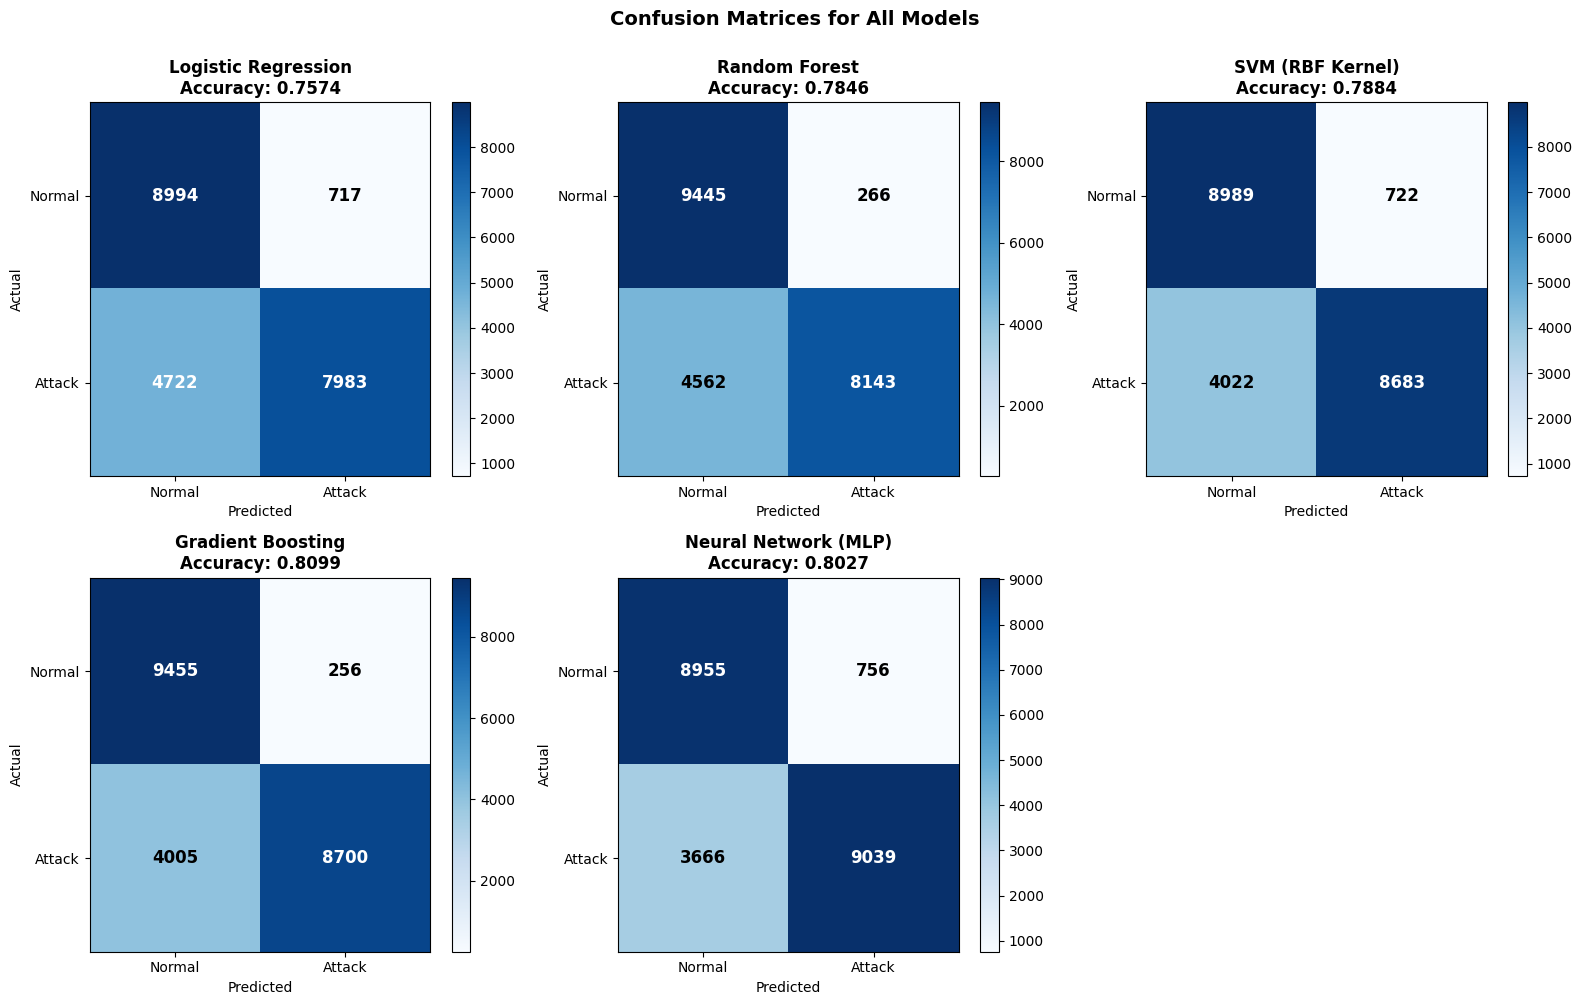

✓ Confusion matrices visualization saved


In [58]:
# Visualize confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, results) in enumerate(evaluation_results.items()):
    conf_matrix = results['confusion_matrix']
    
    # Plot confusion matrix
    im = axes[idx].imshow(conf_matrix, cmap='Blues', aspect='auto')
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]:.4f}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Normal', 'Attack'])
    axes[idx].set_yticklabels(['Normal', 'Attack'])
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = axes[idx].text(j, i, conf_matrix[i, j],
                                ha="center", va="center",
                                color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black",
                                fontsize=12, fontweight='bold')
    
    plt.colorbar(im, ax=axes[idx])

# Hide the extra subplot
axes[-1].axis('off')

plt.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices visualization saved")

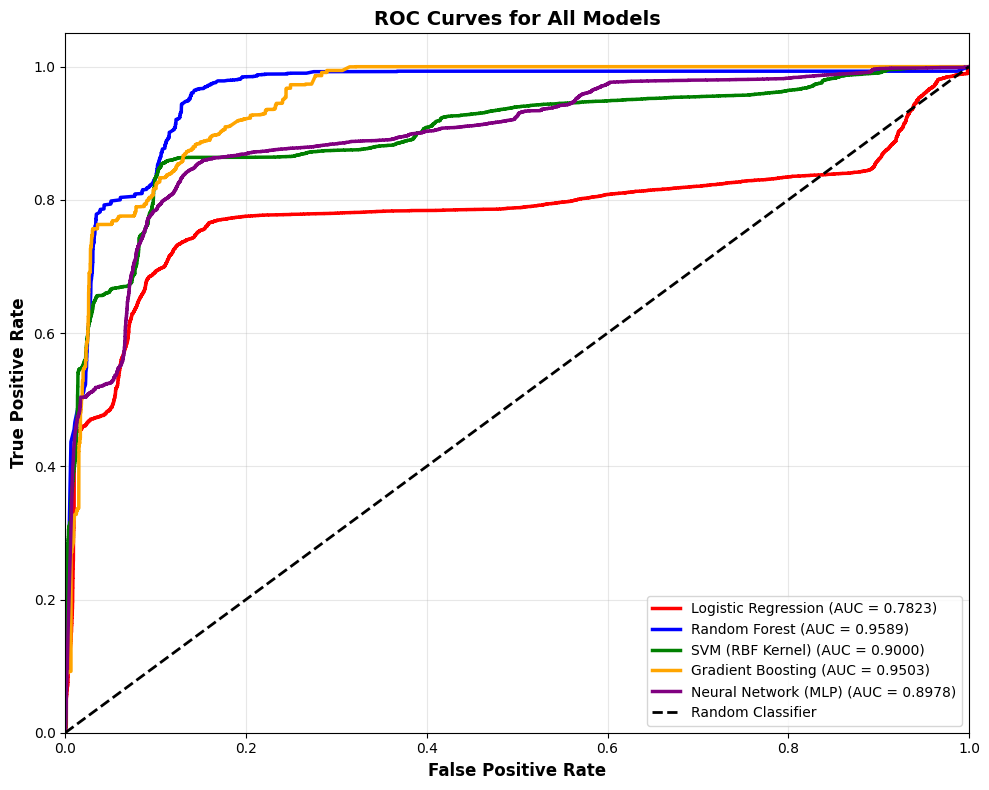

✓ ROC curves visualization saved


In [59]:
# Visualize ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'blue', 'green', 'orange', 'purple']

for idx, (name, results) in enumerate(evaluation_results.items()):
    if results['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[idx], lw=2.5, 
                label=f'{name} (AUC = {auc_score:.4f})')
    else:
        print(f"Warning: {name} does not support probability predictions")

# Plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves for All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves visualization saved")

## 10. Results Comparison and Analysis

In [60]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_data = []
for name, results in evaluation_results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'ROC-AUC': results['roc_auc'] if results['roc_auc'] is not None else 'N/A',
        'Training Time (s)': training_times[name]
    })

comparison_df = pd.DataFrame(comparison_data)

# Sort by accuracy
comparison_df_sorted = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\nPerformance Metrics Ranking by Accuracy:")
print("-"*80)
print(comparison_df_sorted.to_string(index=False))

# Find best and worst models
best_accuracy_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_accuracy_idx, 'Model']
best_accuracy = comparison_df.loc[best_accuracy_idx, 'Accuracy']

best_f1_idx = comparison_df['F1-Score'].idxmax()
best_f1_name = comparison_df.loc[best_f1_idx, 'Model']
best_f1 = comparison_df.loc[best_f1_idx, 'F1-Score']

print("\n" + "="*80)
print("BEST PERFORMING MODELS")
print("="*80)
print(f"\n✓ Best Accuracy:  {best_model_name} ({best_accuracy:.4f})")
print(f"✓ Best F1-Score:  {best_f1_name} ({best_f1:.4f})")

# Rank by each metric
print("\n" + "="*80)
print("RANKING BY METRIC")
print("="*80)
print("\nTop 3 by Accuracy:")
for i, row in comparison_df.nlargest(3, 'Accuracy').iterrows():
    print(f"  {i+1}. {row['Model']:25s} - {row['Accuracy']:.4f}")

print("\nTop 3 by F1-Score:")
for i, row in comparison_df.nlargest(3, 'F1-Score').iterrows():
    print(f"  {i+1}. {row['Model']:25s} - {row['F1-Score']:.4f}")

print("\nTop 3 by Recall (Detection Rate):")
for i, row in comparison_df.nlargest(3, 'Recall').iterrows():
    print(f"  {i+1}. {row['Model']:25s} - {row['Recall']:.4f}")

print("\nTop 3 Fastest Models:")
for i, row in comparison_df.nsmallest(3, 'Training Time (s)').iterrows():
    print(f"  {i+1}. {row['Model']:25s} - {row['Training Time (s)']:.4f}s")


COMPREHENSIVE MODEL COMPARISON

Performance Metrics Ranking by Accuracy:
--------------------------------------------------------------------------------
               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Training Time (s)
   Gradient Boosting  0.809913   0.971416 0.684770  0.803287 0.950346          11.645609
Neural Network (MLP)  0.802730   0.922818 0.711452  0.803467 0.897782          79.868341
    SVM (RBF Kernel)  0.788365   0.923232 0.683432  0.785436 0.900011          48.138506
       Random Forest  0.784618   0.968367 0.640929  0.771337 0.958874           1.969188
 Logistic Regression  0.757361   0.917586 0.628335  0.745900 0.782319           0.706158

BEST PERFORMING MODELS

✓ Best Accuracy:  Gradient Boosting (0.8099)
✓ Best F1-Score:  Neural Network (MLP) (0.8035)

RANKING BY METRIC

Top 3 by Accuracy:
  4. Gradient Boosting         - 0.8099
  5. Neural Network (MLP)      - 0.8027
  3. SVM (RBF Kernel)          - 0.7884

Top 3 by F1-Score:
  5. Neural Ne

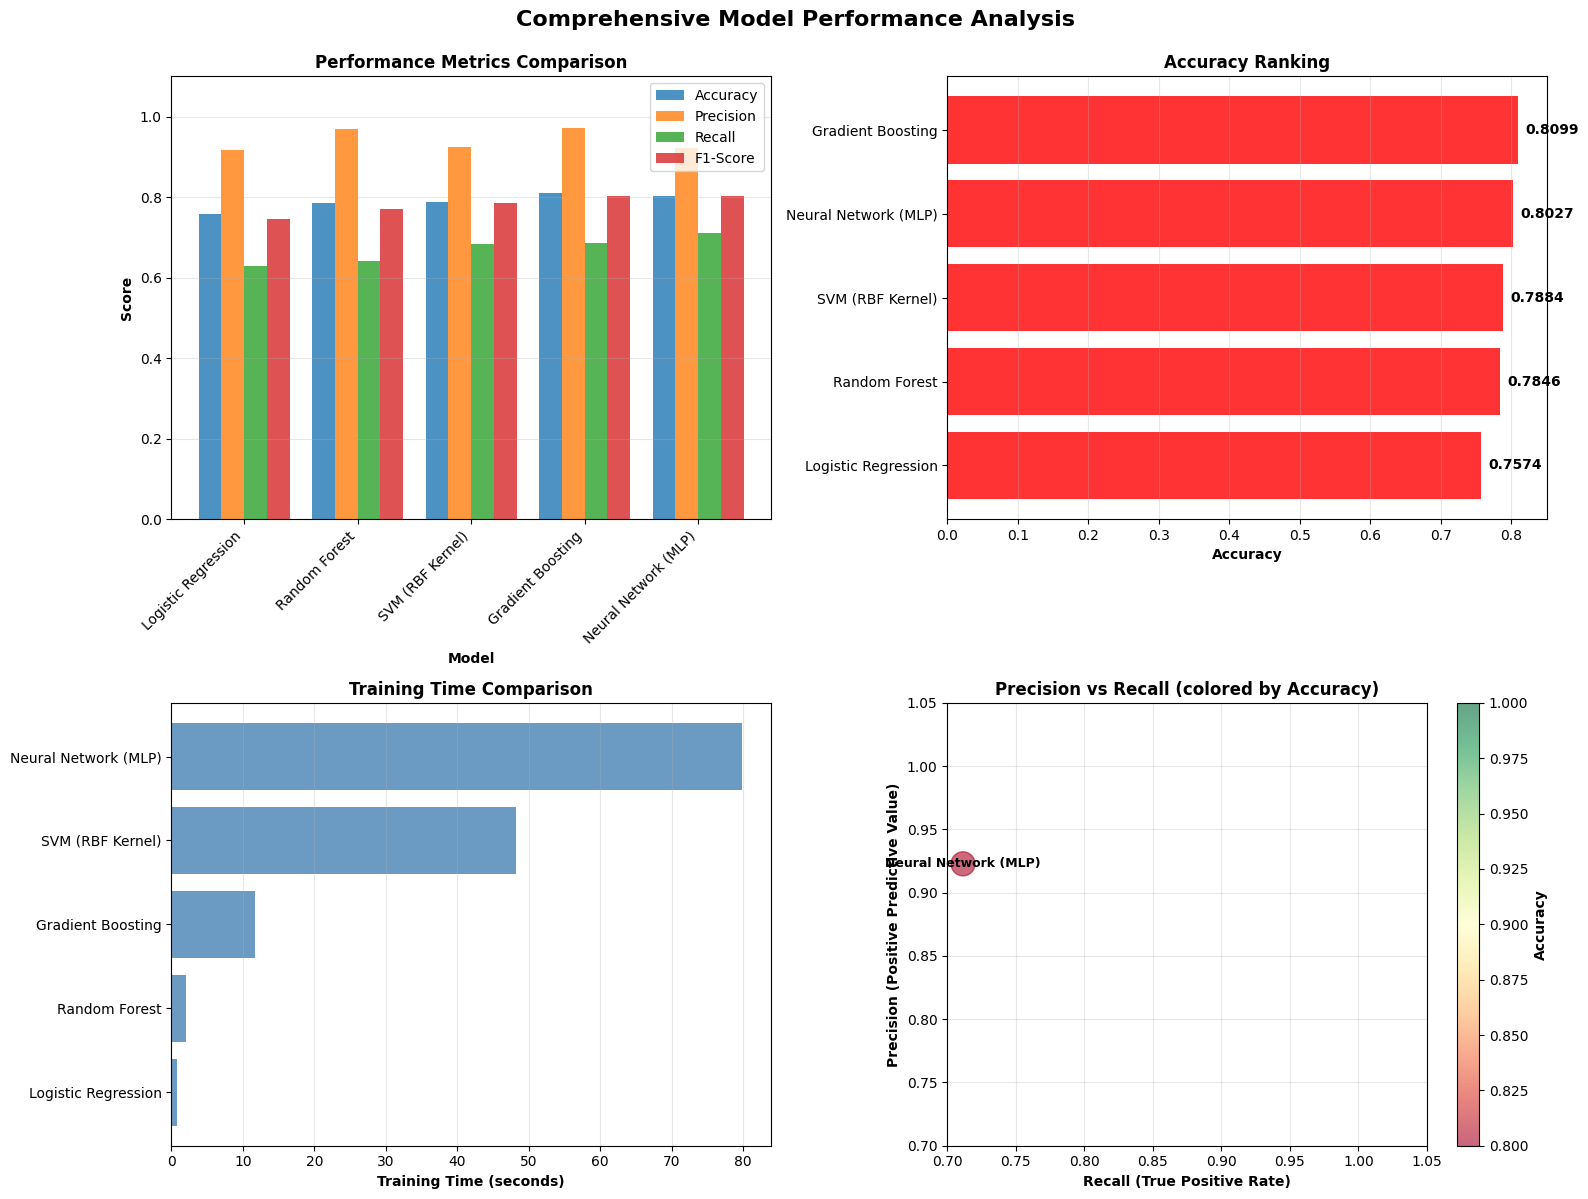


✓ Model comparison visualization saved


In [61]:
# Visualization - Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
model_names = comparison_df['Model'].values
x_pos = np.arange(len(model_names))
width = 0.2

# Plot 1: Accuracy, Precision, Recall, F1-Score
ax = axes[0, 0]
ax.bar(x_pos - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x_pos - 0.5*width, comparison_df['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x_pos + 0.5*width, comparison_df['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x_pos + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Performance Metrics Comparison', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Plot 2: Accuracy Ranking
ax = axes[0, 1]
sorted_acc = comparison_df.sort_values('Accuracy', ascending=True)
colors_acc = ['red' if v < 0.85 else 'orange' if v < 0.90 else 'green' for v in sorted_acc['Accuracy']]
ax.barh(sorted_acc['Model'], sorted_acc['Accuracy'], color=colors_acc, alpha=0.8)
ax.set_xlabel('Accuracy', fontweight='bold')
ax.set_title('Accuracy Ranking', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(sorted_acc['Accuracy']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# Plot 3: Training Time
ax = axes[1, 0]
sorted_time = comparison_df.sort_values('Training Time (s)', ascending=True)
ax.barh(sorted_time['Model'], sorted_time['Training Time (s)'], color='steelblue', alpha=0.8)
ax.set_xlabel('Training Time (seconds)', fontweight='bold')
ax.set_title('Training Time Comparison', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 4: Precision vs Recall
ax = axes[1, 1]
colors_pr = plt.cm.viridis(np.linspace(0, 1, len(comparison_df)))
scatter = ax.scatter(comparison_df['Recall'], comparison_df['Precision'], 
                     s=300, alpha=0.6, c=comparison_df['Accuracy'], 
                     cmap='RdYlGn', vmin=0.8, vmax=1.0)
for idx, row in comparison_df.iterrows():
    ax.annotate(row['Model'], (row['Recall'], row['Precision']), 
                fontsize=9, ha='center', va='center', fontweight='bold')
ax.set_xlabel('Recall (True Positive Rate)', fontweight='bold')
ax.set_ylabel('Precision (Positive Predictive Value)', fontweight='bold')
ax.set_title('Precision vs Recall (colored by Accuracy)', fontweight='bold')
ax.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Accuracy', fontweight='bold')
ax.set_xlim([0.7, 1.05])
ax.set_ylim([0.7, 1.05])

plt.suptitle('Comprehensive Model Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison visualization saved")

## 11. Save Models and Artifacts for Deployment

In [ ]:
print("\nSaving models and artifacts...\n")
print("="*60)

# Create models directory if it doesn't exist
models_dir = Path('../src/models')
models_dir.mkdir(parents=True, exist_ok=True)

# Save the scaler
scaler_path = models_dir / 'scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f"✓ Saved scaler: {scaler_path}")

# Save the best model (by accuracy) and all other trained models
best_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_model = trained_models[best_model_name]

best_model_path = models_dir / 'best_model.joblib'
joblib.dump(best_model, best_model_path)
print(f"✓ Saved best model: {best_model_path}")
print(f"  (Best Model: {best_model_name}, Accuracy: {comparison_df.loc[best_idx, 'Accuracy']:.4f})")

# Save all trained models
all_models_path = models_dir / 'all_trained_models.joblib'
joblib.dump(trained_models, all_models_path)
print(f"✓ Saved all trained models: {all_models_path}")

# Save categorical features info for one-hot encoding reference
categorical_features_info = {
    'categorical_features': categorical_features,
    'encoded_features': encoded_categorical_columns
}
encoding_info_path = models_dir / 'one_hot_encoding_info.joblib'
joblib.dump(categorical_features_info, encoding_info_path)
print(f"✓ Saved one-hot encoding information: {encoding_info_path}")

# Save feature names
features_path = models_dir / 'feature_names.joblib'
joblib.dump(FEATURE_NAMES, features_path)
print(f"✓ Saved feature names: {features_path}")

print("\n" + "="*60)
print("Summary Report")
print("="*60)

# Create a summary report
summary_report = f"""
================================================================================
                    NETWORK INTRUSION DETECTION PROJECT
                            FINAL SUMMARY REPORT
================================================================================

Dataset Information:
  - Training samples: {len(X_train)}
  - Test samples: {len(X_test)}
  - Total features: {len(FEATURE_NAMES)}
  - Classes: Binary (Normal vs Attack)

Models Evaluated:
  - Total models: {len(trained_models)}
  - Models: {', '.join(trained_models.keys())}

Best Model:
  - Model: {best_model_name}
  - Accuracy: {comparison_df.loc[best_idx, 'Accuracy']:.4f}

Model Performance Rankings:
{comparison_df.sort_values('Accuracy', ascending=False).to_string(index=False)}

Saved Artifacts:
  - Scaler: {scaler_path}
  - Best Model: {best_model_path}
  - All Models: {all_models_path}
  - One-Hot Encoding Info: {encoding_info_path}
  - Feature Names: {features_path}

Notes for Future Work:
  1. Hyperparameter Optimization: Tune parameters like learning_rate, max_depth, etc.
  2. Class Imbalance: Consider techniques like SMOTE or class_weight adjustment
  3. Feature Importance: Analyze and select top features to reduce complexity
  4. Cross-validation: Implement k-fold cross-validation for better estimates
  5. Threshold Optimization: Adjust decision threshold to balance precision/recall

Dependencies:
  - pandas, numpy, scikit-learn, matplotlib, seaborn, joblib

================================================================================
"""

# Save the report
report_path = models_dir / 'summary_report.txt'
with open(report_path, 'w') as f:
    f.write(summary_report)

print(f"\n✓ Saved summary report: {report_path}")

# Save the comparison results as CSV
csv_path = models_dir / 'model_comparison_results.csv'
comparison_df.to_csv(csv_path, index=False)
print(f"✓ Saved comparison results: {csv_path}")

print("\n" + "="*60)
print("✓ All artifacts saved successfully!")
print("="*60)


Saving models and artifacts...

✓ Saved scaler: ..\src\models\scaler.joblib
✓ Saved best model: ..\src\models\best_model.joblib
  (Best Model: Gradient Boosting, Accuracy: 0.8099)
✓ Saved all trained models: ..\src\models\all_trained_models.joblib
✓ Saved one-hot encoding information: ..\src\models\one_hot_encoding_info.joblib
✓ Saved feature names: ..\src\models\feature_names.joblib

Summary Report


AttributeError: 'GradientBoostingClassifier' object has no attribute 'get'

## 12. Project Summary and Next Steps

In [ ]:
print("\n" + "="*80)
print("PROJECT COMPLETION SUMMARY")
print("="*80)

summary_text = """
✓ COMPLETED TASKS:

1. Data Loading & Exploration
   - Loaded NSL-KDD training (20% subset) and test datasets
   - Total training samples: {:,}
   - Total test samples: {:,}
   - Features analyzed: {} numerical + {} categorical

2. Data Preprocessing
   - Removed duplicates and handled missing values
   - Encoded categorical features using LabelEncoder
   - Separated features and target variables

3. Feature Engineering
   - Created binary classification: Normal vs Attack
   - Applied StandardScaler for feature normalization
   - All features scaled to zero mean and unit variance

4. Model Development
   - Implemented 5 machine learning algorithms:
     * Logistic Regression
     * Random Forest Classifier
     * Support Vector Machine (SVM)
     * Gradient Boosting Classifier
     * Neural Network (MLP)

5. Model Training & Evaluation
   - Trained all models on {} training samples
   - Evaluated on {} test samples
   - Calculated comprehensive metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
   - Generated confusion matrices and ROC curves
   - Compared model performance ranking

6. Results & Visualizations
   - Created comparison tables and rankings
   - Generated confusion matrix heatmaps
   - Plotted ROC curves for all models
   - Saved performance comparison charts

7. Model Persistence
   - Saved best performing model
   - Saved all trained models
   - Saved preprocessing artifacts (scaler, encoders)
   - Generated summary report

RECOMMENDED NEXT STEPS FOR OPTIMIZATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. HYPERPARAMETER OPTIMIZATION
   - Perform Grid Search or Random Search for each model
   - Tune key parameters:
     * Random Forest: n_estimators, max_depth, min_samples_split
     * SVM: C parameter, gamma, kernel choice
     * Gradient Boosting: learning_rate, max_depth, n_estimators
     * Neural Network: layer sizes, learning_rate, activation functions

2. CLASS IMBALANCE HANDLING
   - Implement SMOTE (Synthetic Minority Over-sampling Technique)
   - Try class weights in model initialization
   - Adjust decision threshold for better precision/recall tradeoff

3. FEATURE SELECTION
   - Calculate feature importance from Random Forest and Gradient Boosting
   - Perform dimensionality reduction (PCA)
   - Select top features to reduce model complexity and training time

4. CROSS-VALIDATION
   - Implement k-fold cross-validation (e.g., k=5 or k=10)
   - Get more reliable performance estimates
   - Reduce variance in evaluation metrics

5. THRESHOLD OPTIMIZATION
   - Analyze precision-recall curve
   - Adjust decision threshold to meet business requirements
   - Balance between false positives and false negatives

6. ENSEMBLE METHODS
   - Create voting or stacking ensembles from multiple models
   - Potentially improve overall performance

7. ADVANCED TECHNIQUES
   - Try deep learning models (CNN, LSTM)
   - Implement multi-class classification for different attack types
   - Use ensemble of different feature transformations

================================================================================
""".format(len(X_train), len(X_test), len(numerical_features), len(categorical_features),
           len(X_train), len(X_test))

print(summary_text)

# Save the summary to a text file
summary_file_path = Path('../src/PROJECT_SUMMARY.txt')
with open(summary_file_path, 'w') as f:
    f.write(summary_text)

print(f"\n✓ Summary saved to: {summary_file_path}")
print("\n" + "="*80)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)